## Deep Learning Model (Option C)

Define, train, and evaluate the deep learning classifier. Record training setup and report final metrics.


In [1]:
from pathlib import Path
import sys

# Add project root so src imports work when running from notebooks/.
sys.path.append(str(Path().resolve().parent))

from src.config import (
    PART1_KAGGLE_DIR,
    PART1_TRAIN_DIR,
    PART1_TEST_DIR,
)

# Validate Part 1 layout only (Part 2 is not needed for Option C)
assert PART1_TRAIN_DIR.exists(), f"Training data missing: {PART1_TRAIN_DIR}"
assert PART1_TEST_DIR.exists(), f"Test data missing: {PART1_TEST_DIR}"

print("Data paths validated:")
print(f"- Part 1 root : {PART1_KAGGLE_DIR}")
print(f"- Train       : {PART1_TRAIN_DIR}")
print(f"- Test        : {PART1_TEST_DIR}")

Data paths validated:
- Part 1 root : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification
- Train       : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification\train\train
- Test        : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification\test\test


### Imports & Device Setup

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

from src.config import (
    IMG_SIZE_CNN,
    CLASS_NAMES,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
)
from src.utils import (
    load_labeled_images,
    split_data,
    get_pytorch_dataloaders,
    load_test_images,
    generate_submission_csv,
    build_gpu_augmentation,
)
from src.evaluation import compute_metrics, compute_confusion_matrix
from src.visualization import (
    plot_confusion_matrix,
    plot_training_history,
    plot_sample_predictions,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load Full Dataset

Load all labeled images at 224×224, then create a fixed 80/20 stratified train/val split.
The validation set stays constant across all progressive training runs for fair comparison.

> **Note:** Loading the full dataset into RAM can use ~15 GB.

In [3]:
# Load the FULL dataset (no cap)
X, y = load_labeled_images(img_size=IMG_SIZE_CNN, grayscale=False, max_samples=None)
print(f"Full dataset: {X.shape}, labels: {y.shape}")
print(f"  Class 0 (cat): {(y == 0).sum()},  Class 1 (dog): {(y == 1).sum()}")

# Fixed 80/20 stratified split — the val set stays the same for every run
X_train_full, X_val, y_train_full, y_val = split_data(X, y, test_size=0.2, random_state=42)
print(f"Train (full): {X_train_full.shape}, Val: {X_val.shape}")

# Progressive sample sizes (per-class counts used during training)
SAMPLE_SIZES = [500, 1000, 2000, 4000, len(X_train_full)]
BATCH_SIZE = 32

print(f"\nProgressive training sizes: {SAMPLE_SIZES}")

Loading dogs: 100%|██████████| 9979/9979 [00:13<00:00, 750.96it/s]


Full dataset: (20000, 224, 224, 3), labels: (20000,)
  Class 0 (cat): 10021,  Class 1 (dog): 9979
Train (full): (16000, 224, 224, 3), Val: (4000, 224, 224, 3)

Progressive training sizes: [500, 1000, 2000, 4000, 16000]


### Helper Functions

Define the model factory and training/evaluation loops used in the progressive training loop below.

In [4]:
from tqdm import tqdm

# GPU augmentation — applied on-device inside the training loop (no CPU bottleneck)
gpu_augment = build_gpu_augmentation(img_size=IMG_SIZE_CNN)


def build_model(device):
    """Create a fresh ResNet-50 with frozen backbone and 2-class head."""
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 2),
    )
    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer, device, augment=None):
    """Run one training epoch. Returns (avg_loss, accuracy).
    If *augment* is provided, it is applied per-image on the GPU batch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        if augment is not None:
            images = torch.stack([augment(img) for img in images])
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


print("Helper functions defined.")

Helper functions defined.


### Progressive Training

For each dataset size in `SAMPLE_SIZES`, train a fresh ResNet-50 through two phases:

1. **Phase 1 — Head only** (8 epochs, lr=1e-3, cosine annealing)
2. **Phase 2 — Full fine-tuning** (12 epochs, lr=1e-5, cosine annealing)

Improvements over initial run: ResNet-50 backbone, data augmentation (random flips,
rotation, colour jitter, random erasing), cosine-annealing LR, dropout in head.

In [5]:
from sklearn.utils import resample

NUM_EPOCHS_HEAD = 8
NUM_EPOCHS_FULL = 12

progressive_results = []   # list of dicts: {n_train, best_val_acc, history, ...}

for n_samples in SAMPLE_SIZES:
    print(f"\n{'='*60}")
    print(f"Training with {n_samples} images (out of {len(X_train_full)})")
    print(f"{'='*60}")

    # --- Subsample the training set (stratified) ---
    if n_samples < len(X_train_full):
        X_sub, y_sub = resample(
            X_train_full, y_train_full,
            n_samples=n_samples, stratify=y_train_full, random_state=42,
        )
    else:
        X_sub, y_sub = X_train_full, y_train_full

    # normalize_train=False keeps training tensors in [0,1] so GPU augmentation
    # (ColorJitter etc.) works correctly; normalization is inside gpu_augment.
    train_loader, val_loader = get_pytorch_dataloaders(
        X_sub, y_sub, X_val, y_val, batch_size=BATCH_SIZE, img_size=IMG_SIZE_CNN,
        normalize_train=False,
    )
    print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    # --- Fresh model ---
    model = build_model(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Head-only parameters
    head_params = [p for p in model.fc.parameters() if p.requires_grad]
    optimizer = optim.Adam(head_params, lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_HEAD)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    # Phase 1: Head only (with GPU augmentation)
    print(f"  Phase 1: FC head only for {NUM_EPOCHS_HEAD} epochs")
    for epoch in range(1, NUM_EPOCHS_HEAD + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, augment=gpu_augment)
        vl, va = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        print(f"    Epoch {epoch}/{NUM_EPOCHS_HEAD} — TrL:{tl:.4f} TrA:{ta:.4f} VL:{vl:.4f} VA:{va:.4f}")
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Phase 2: Full fine-tuning (with GPU augmentation)
    for param in model.parameters():
        param.requires_grad = True
    optimizer_ft = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=NUM_EPOCHS_FULL)

    print(f"  Phase 2: Full fine-tuning for {NUM_EPOCHS_FULL} epochs")
    for epoch in range(1, NUM_EPOCHS_FULL + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer_ft, device, augment=gpu_augment)
        vl, va = evaluate(model, val_loader, criterion, device)
        scheduler_ft.step()
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        print(f"    Epoch {epoch}/{NUM_EPOCHS_FULL} — TrL:{tl:.4f} TrA:{ta:.4f} VL:{vl:.4f} VA:{va:.4f}")
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    progressive_results.append({
        "n_train": n_samples,
        "best_val_acc": best_val_acc,
        "history": history,
    })
    print(f"  ✓ Best val accuracy: {best_val_acc:.4f}")

# Restore the best weights from the LAST (full-dataset) run for downstream use
model.load_state_dict(best_state)
model = model.to(device)

# Also keep the last val_loader for evaluation cells below
print("\n--- Progressive Training Summary ---")
for r in progressive_results:
    print(f"  {r['n_train']:>6d} images → val acc = {r['best_val_acc']:.4f}")
print(f"\nFinal model uses {progressive_results[-1]['n_train']} training images.")


Training with 500 images (out of 16000)
  Train batches: 16, Val batches: 125
  Phase 1: FC head only for 8 epochs


    Epoch 1/8 — TrL:0.5424 TrA:0.7540 VL:0.3580 VA:0.9750


    Epoch 2/8 — TrL:0.3208 TrA:0.9420 VL:0.2453 VA:0.9790


    Epoch 3/8 — TrL:0.2609 TrA:0.9500 VL:0.2146 VA:0.9802


    Epoch 4/8 — TrL:0.2289 TrA:0.9640 VL:0.2015 VA:0.9818


...

    Epoch 8/12 — TrL:0.1354 TrA:0.9951 VL:0.1309 VA:0.9950


    Epoch 9/12 — TrL:0.1325 TrA:0.9960 VL:0.1305 VA:0.9948


    Epoch 10/12 — TrL:0.1338 TrA:0.9952 VL:0.1309 VA:0.9948


    Epoch 11/12 — TrL:0.1331 TrA:0.9953 VL:0.1306 VA:0.9950


    Epoch 12/12 — TrL:0.1316 TrA:0.9960 VL:0.1308 VA:0.9952
  ✓ Best val accuracy: 0.9958

--- Progressive Training Summary ---
     500 images → val acc = 0.9872
    1000 images → val acc = 0.9918
    2000 images → val acc = 0.9922
    4000 images → val acc = 0.9938
   16000 images → val acc = 0.9958

Final model uses 16000 training images.


### Training Curves (Final Run) & Data Scaling Curve

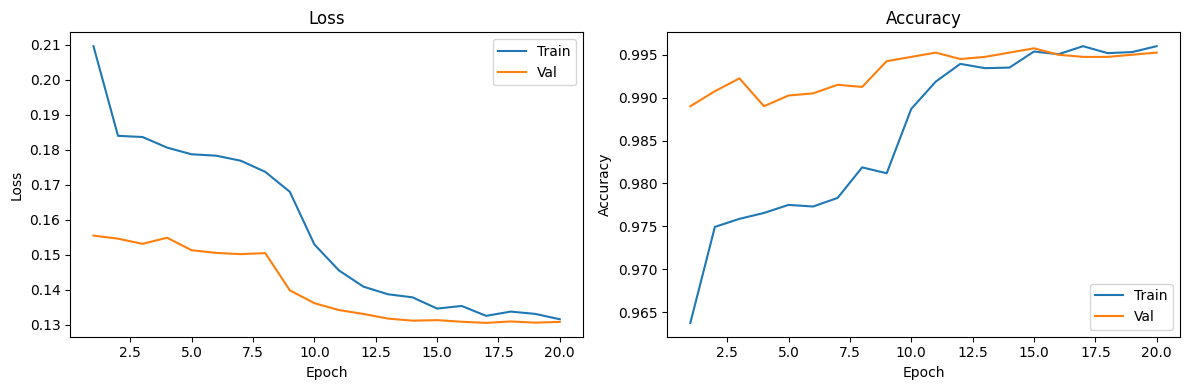

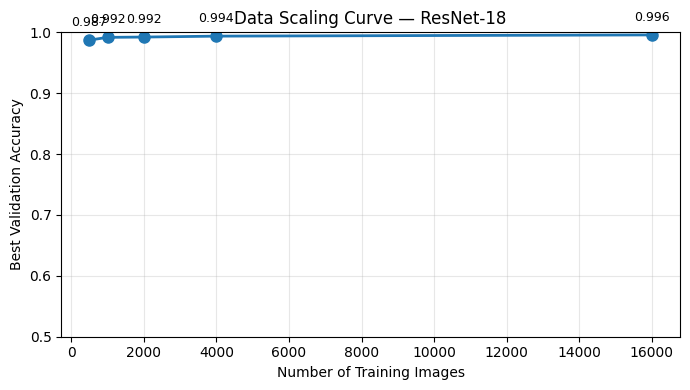

Saved data_scaling_curve_optionC.png


In [11]:
import matplotlib.pyplot as plt

# 1) Training history from the final (full-dataset) run
final_history = progressive_results[-1]["history"]
plot_training_history(final_history, save_path=FIGURES_DIR / "training_history_optionC.png")

# 2) Data scaling curve: val accuracy vs training set size
sizes = [r["n_train"] for r in progressive_results]
accs  = [r["best_val_acc"] for r in progressive_results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, accs, "o-", linewidth=2, markersize=8)
ax.set_xlabel("Number of Training Images")
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Data Scaling Curve — ResNet-18")
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)
for s, a in zip(sizes, accs):
    ax.annotate(f"{a:.3f}", (s, a), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "data_scaling_curve_optionC.png", dpi=150)
plt.show()
print("Saved data_scaling_curve_optionC.png")

### Evaluation on Internal Test Split

Run inference on the held-out validation set (Internal Test Split) and compute classification metrics + confusion matrix.

In [7]:
# Collect predictions on the validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Inference"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Compute metrics
metrics_c = compute_metrics(y_true, y_pred)
print("Option C (CNN — ResNet-18) Metrics:")
for k, v in metrics_c.items():
    print(f"  {k:>10s}: {v:.4f}")

# Confusion matrix
cm = compute_confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Inference: 100%|██████████| 125/125 [00:05<00:00, 22.77it/s]


Option C (CNN — ResNet-18) Metrics:
    accuracy: 0.9958
   precision: 0.9970
      recall: 0.9945
          f1: 0.9957

Confusion Matrix:
[[1998    6]
 [  11 1985]]


### Confusion Matrix & Sample Predictions

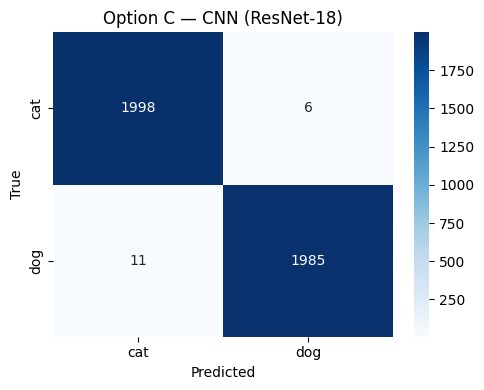

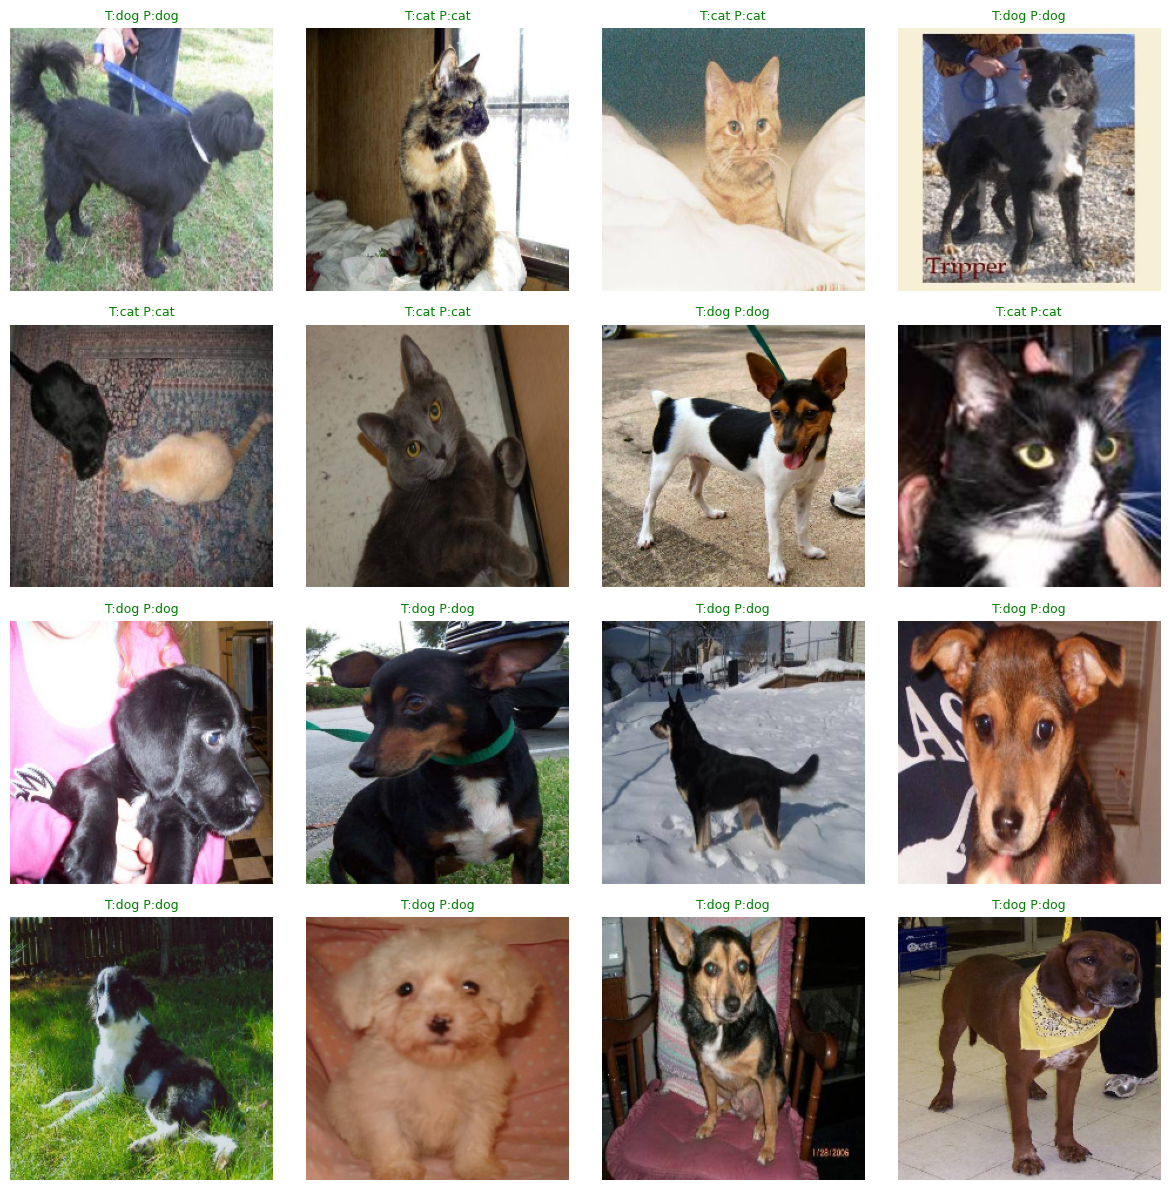

In [ ]:
plot_confusion_matrix(
    cm,
    class_names=CLASS_NAMES,
    title="Option C — CNN (ResNet-50)",
    save_path=FIGURES_DIR / "confusion_matrix_optionC.png",
)

plot_sample_predictions(
    X_val,        # un-normalized numpy images for display
    y_true,
    y_pred,
    class_names=CLASS_NAMES,
    n=16,
    save_path=FIGURES_DIR / "sample_predictions_optionC.png",
)

### Save Model & Metrics

In [13]:
import json

# Save model weights
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "option_c_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Save metrics as JSON for notebook 04 to load
metrics_path = MODELS_DIR / "metrics_optionC.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_c, f, indent=2)
print(f"Metrics saved to {metrics_path}")
print(metrics_c)

Model saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\models\option_c_cnn.pth
Metrics saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\models\metrics_optionC.json
{'accuracy': 0.99575, 'precision': 0.9969864389753893, 'recall': 0.9944889779559118, 'f1': 0.9957361424630048}


### Kaggle Submission (with TTA)

Generate predictions on the unlabeled Kaggle Public Test Set using **Test-Time Augmentation**: average softmax probabilities from the original image and its horizontal flip, then take argmax. The label column contains integer class labels: **0 = Cat, 1 = Dog**.

In [14]:
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Load unlabeled test images
X_test, test_ids = load_test_images(img_size=IMG_SIZE_CNN, grayscale=False)
print(f"Test images: {X_test.shape}, IDs: {len(test_ids)}")

# Prepare test tensors (NCHW float)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
X_test_base = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()

# ── Test-Time Augmentation (TTA) ─────────────────────────────────────────
# Average softmax probabilities over the original image + a horizontally-
# flipped copy to improve prediction robustness.
tta_transforms = [
    lambda t: t,                       # identity (original)
    lambda t: torch.flip(t, dims=[3]), # horizontal flip
]

model.eval()
avg_probs = None

for tta_idx, tta_fn in enumerate(tta_transforms):
    X_aug = tta_fn(X_test_base.clone())
    X_aug = torch.stack([normalize(img) for img in X_aug])
    test_ds = TensorDataset(X_aug)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for (images,) in tqdm(test_loader, desc=f"TTA pass {tta_idx+1}/{len(tta_transforms)}"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu()
            all_probs.append(probs)

    probs_tensor = torch.cat(all_probs, dim=0)  # (N, 2)
    if avg_probs is None:
        avg_probs = probs_tensor
    else:
        avg_probs = avg_probs + probs_tensor

avg_probs = avg_probs / len(tta_transforms)
predictions = avg_probs.argmax(dim=1).numpy()

# Write CSV with integer labels (Kaggle expects 0/1, not probabilities)
submission_path = generate_submission_csv(
    test_ids, predictions, OUTPUTS_DIR / "submission_optionC.csv"
)
print(f"Submission saved to {submission_path}  ({len(test_ids)} rows)")
print(f"  Dogs: {(predictions == 1).sum()}, Cats: {(predictions == 0).sum()}")

Loading test images: 100%|██████████| 5000/5000 [00:06<00:00, 789.81it/s]


Test images: (5000, 224, 224, 3), IDs: 5000


TTA pass 2/2: 100%|██████████| 157/157 [00:06<00:00, 25.37it/s]

Submission saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\submission_optionC.csv  (5000 rows)
  Dogs: 2526, Cats: 2474
